# Image augmentation

**Learning objective:** Create label-preserving image variations inside the TensorFlow model and inspect the transformed examples.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])


2026-09-21 07:16:07.592769: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974967.608544    4130 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974967.612916    4130 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:16:09.443562: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


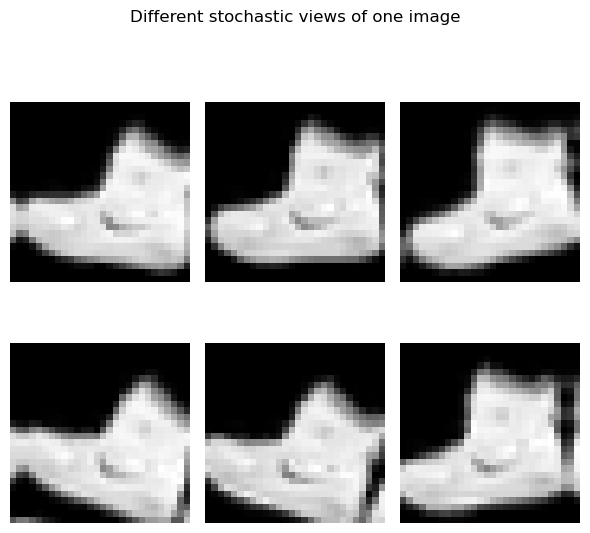

In [2]:
(x,y),_=tf.keras.datasets.fashion_mnist.load_data(); img=x[0].astype("float32")/255
aug=tf.keras.Sequential([tf.keras.layers.RandomRotation(.06,seed=SEED),tf.keras.layers.RandomTranslation(.08,.08,seed=SEED+1)])
batch=tf.repeat(img[None,:,:,None],6,axis=0); out=aug(batch,training=True).numpy()
fig,axes=plt.subplots(2,3,figsize=(6,6))
for ax,a in zip(axes.flat,out): ax.imshow(a[:,:,0],cmap="gray"); ax.axis("off")
plt.suptitle("Different stochastic views of one image"); plt.tight_layout(); plt.show()


Augmentation should encode plausible invariances. Transformations that change the semantic label create corrupted supervision rather than regularization.


In [3]:
print("augmentation output shape:",out.shape,"value range:",(float(out.min()),float(out.max())))


augmentation output shape: (6, 28, 28, 1) value range: (0.0, 0.9429926872253418)
